In [ ]:
%load_ext autoreload
%autoreload 2

import wfdb
import tslearn
import pandas as pd
import numpy as np
import scipy as sc

import os
import sys
import re

import matplotlib.pyplot as plt
import seaborn as sns
# https://github.com/MIT-LCP/wfdb-python/blob/main/demo.ipynb

import gc
import itertools
from tqdm import tqdm

# MIMIC-IV ECG Database in August 2023~!!!!
# https://physionet.org/content/mimic-iv-ecg/0.2/
# https://towardsdatascience.com/audio-classification-with-deep-learning-in-python-cf752b22ba07

## Interpretation

We have multiple bands of timeseries data, coming from different leads.
For the standard 12-lead ECG the bands are denoted as
* I
* II
* III
* avL
* avR
* avF
* v1
* v2
* v3
* v4
* v5
* v6

These leads have different associations.

* Inferior wall: II/III/avF
* Lateral  wall of LV: I/avL/v5/v6
* RV: avR/v1/v2
* Anteroseptal: v1/v2/v3/v4

* vertical plane: I/II/II
* e-activity in vertical plane: avR/avL/avF
* e-activity in horizontal plane: v1-v6

PR interval:
QRS complex:
ST-segment:

HR:
* $<60$ bradycardia
* $>100$ tachycardia
I.e. take moving average of HR

QRS interval:
* $<=0.08$ seconds is narrow
* $>=0.16$ seconds is wide 
I.e. take ratio of QRS interval and $0.12$

Rythm irregularity:
* R-R interval constant is regular
* R-R interval not constant is irregular
I.e. take moving SD of R-R

P-wave: up/down
T-wave: up/down

P-wave should be up in II and down in avR and should be followed by a QRS.

T-wave should be up in v1-v2/III

T-wave inversion in avL only, then potential inferior MI. 

P-R interval: should be about 0.2 seconds.


Elevation:
* S-T segment elevation
* S-T segment depression
    * downsloping
    * horizontal
    * upsloping 

Diagnoses:
* WPW
* BBB, LBBB
* A-fib
* A-flutter
* MAT
* V.tach
* STEMI
* NSTEMI
* pericarditis
* vasospasm
* p. embolism
* l.v. aneurysm
* l.v. hypertrophy
* (posterior) MI
* Digoxin toxicity
* benign early polarisation
* hypothermia
* hypercalcemia
* brugada syndrome
* ischemia
* hyperkalemia
* hypermagnesemia


[VIDEO](https://www.youtube.com/watch?v=TTYGxK1DNKA)

In [ ]:
os.chdir("/media/koekiemonster/DATA-FAST/ecg")
sampling_method = "trimmed_segment"

"The data and annotations in most PhysioBank databases are stored in a Waveform Database (WFDB) format, which contains two standard categories:

**MIT Format**
* MIT Signal files (.dat) are binary files containing samples of digitized signals. These store the waveforms, but they cannot be interpreted properly without their corresponding header files. These files are in the form: RECORDNAME.dat.
* MIT Header files (.hea) are short text files that describe the contents of associated signal files. These files are in the form: RECORDNAME.hea.
* MIT Annotation files are binary files containing annotations (labels that generally refer to specific samples in associated signal files). Annotation files should be read with their associated header files. If you see files in a directory called RECORDNAME.dat, or RECORDNAME.hea, any other file with the same name but different extension, for example RECORDNAME.atr, is an annotation file for that record.

**European Data Format (EDF)**
* EDF files contain digital signals stored in their standard international format. EDF files store their header information at the beginning of the file, as opposed to MIT format which has a separate header file. Since recent versions of the WFDB library can read them directly, EDF is a WFDB and PhysioBank-compatible format. EDF files may also have associated annotation files. For example if a directory contains RECORDNAME.edf and RECORDNAME.edf.qrs, the .qrs file is the annotation file associated with the record.
* EDF+ files are EDF files that also contain annotations encoded as signals."

In python you can use e.g. the library ```wfdb```.

In [ ]:
re_age = re.compile(r'Age:\s?(\d+)') 
re_sex = re.compile(r'Sex:\s?(\w+)')
re_diagnosis = re.compile(r'Diagnosis report:\s?(.+)')

ts_collection = []

patients = [_dir for _dir in os.listdir('wilson-central-terminal-ecg-database-1.0.1') if 'patient' in _dir]
for patient in tqdm(patients):
    meas_files = os.listdir(f'wilson-central-terminal-ecg-database-1.0.1/{patient}')
    hea_files = [f.split('.')[0] for f in meas_files if '.hea' in f]
    for hea in hea_files:
        rec_path = f'wilson-central-terminal-ecg-database-1.0.1/{patient}/'+hea
        #record = wfdb.rdrecord(rec_path)
        #record.__dict__
        #wfdb.rdsamp(rec_path)
        band_names = wfdb.rdheader(rec_path).__dict__['sig_name']
        meta_str = ",".join(wfdb.rdheader(rec_path).__dict__['comments'])
        age  = int(re.findall(re_age, meta_str)[0])
        sex = re.findall(re_sex, meta_str)[0]
        diagnosis = re.findall(re_diagnosis, meta_str)[0]
        tmp = wfdb.rdsamp(rec_path)[0]
        tdf = pd.DataFrame(tmp, columns=band_names)
        tdf['patient'] = patient
        tdf['age'] = age
        tdf['sex'] = sex
        tdf['diagnosis'] = diagnosis
        tdf['segment'] = hea
        ts_collection.append(tdf)
time_df = pd.concat(ts_collection)
time_df.reset_index(inplace=True)
# drop all columns with the string "Raw" in it
time_df.drop(time_df.filter(regex='Raw').columns, axis=1, inplace=True)
time_df.rename(columns={'index': 'seg_index'}, inplace=True)

meta_cols = ['seg_index', 'age', 'sex', 'diagnosis', 'patient', 'segment']
value_columns = [c for c in time_df.columns if c not in meta_cols]


In [ ]:
def _feature_combiner(df, 
                      value_columns: list=[], 
                      depth=1,
                      mutation_list: list=['AbsDiff']):
    # |A|-|B|
    #   A+B
    #   A*B
    # todo: add lag?
    if len(value_columns)==0:
        value_columns = df.columns.tolist()
    
    df_combo = df.copy()
    for iter in range(depth):
        col_range = len(value_columns)
        col_pairs = [(value_columns[iL], value_columns[iR])
                        for iL in range(col_range) 
                        for iR in range(iL, col_range)]        
        mutation_names = []
        for cp in col_pairs:
            if 'AbsDiff' in mutation_list:
                if cp[0]!=cp[1]:
                    mut_name = 'AbsDiff_'+'_'.join(cp)
                    mutation_names.append(mut_name)
                    kwargs = {mut_name: df[cp[0]].abs() - df[cp[1]].abs()}
                    df_combo = df_combo.assign(**kwargs)
            if 'Sum' in mutation_list:
                if cp[0]!=cp[1]:
                    mut_name = 'Sum'+'_'.join(cp)
                    mutation_names.append(mut_name)
                    kwargs = {mut_name: df[cp[0]] + df[cp[1]]}
                    df_combo = df_combo.assign(**kwargs)            
            if 'Product' in mutation_list:
                mut_name = 'Product'+'_'.join(cp)
                mutation_names.append(mut_name)
                kwargs = {mut_name : df[cp[0]] * df[cp[1]]}
                df_combo = df_combo.assign(**kwargs) 
                
        value_columns += mutation_names    
    return df_combo, value_columns

## Data structure

Per patient have a separate file per segment, each patient has multiple segments, each segment is $10$ seconds.

In [ ]:
meas_columns = ['I', 'II', 'III', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'LA', 'RA', 'LL']

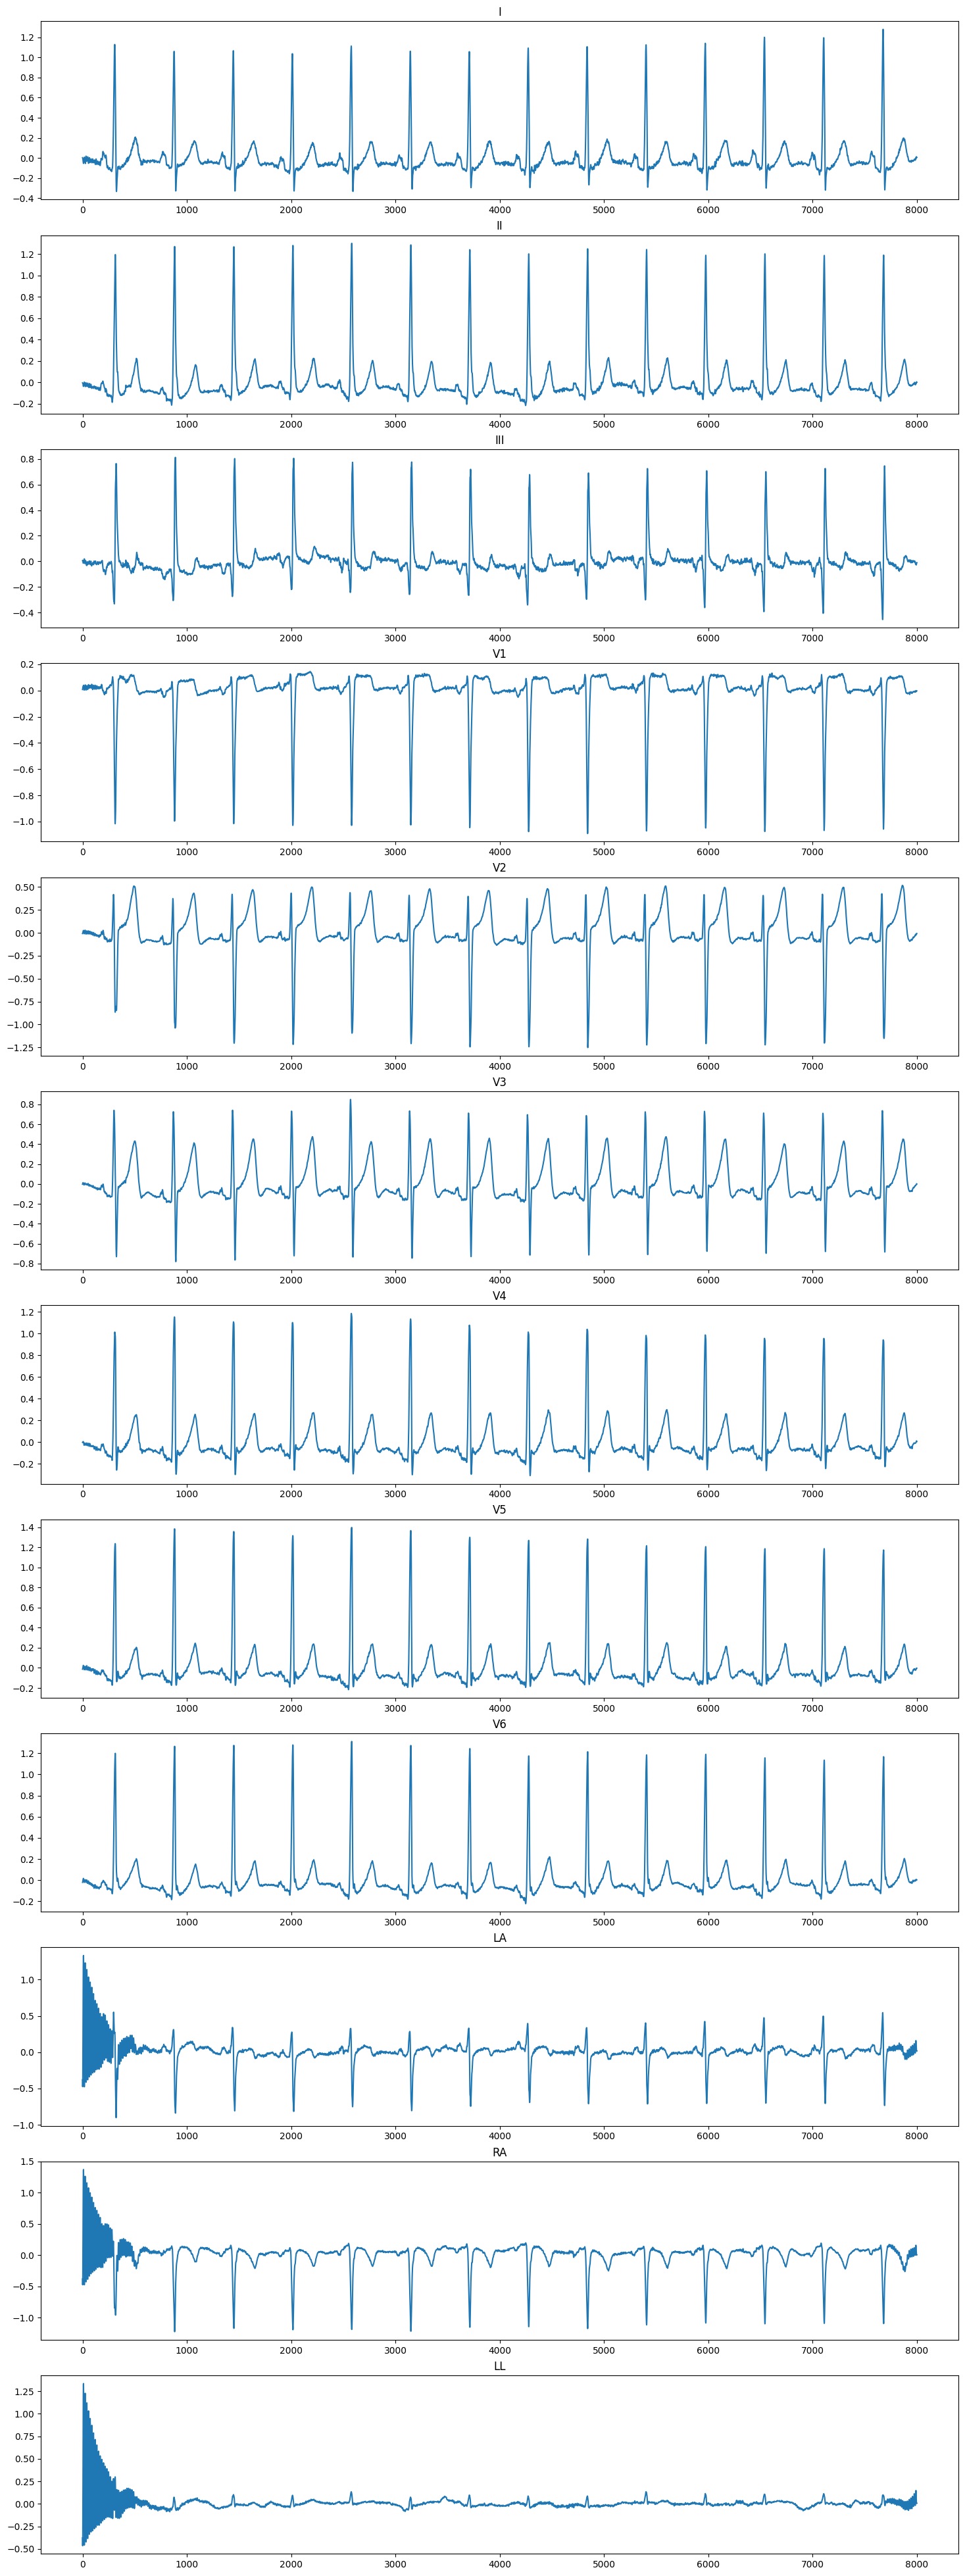

In [6]:
pat = time_df.patient.unique()[9]
fig, ax = plt.subplots(nrows=12, figsize=(18,50))

for idx, col in enumerate(meas_columns, 0):
    x = time_df.loc[(time_df.patient==pat) & (time_df.segment=='seg01')]['seg_index']
    y = time_df.loc[(time_df.patient==pat) & (time_df.segment=='seg01')][col]
    ax[idx].plot(x, y)
    ax[idx].set_title(col)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer
from scipy.signal import butter, lfilter, freqz


In [10]:
# Trim segments
# - beginning and ending of segments are especially noisy
# - start at first peak in one of the channels
def _trim_segment(df, 
                  group_cols: list = ['patient', 'segment'], 
                  meas_columns: list = ['I', 'II', 'III', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'LA', 'RA', 'LL'],
                  quantile_left: float=0.95,
                  quantile_right:  float=0.95,
                  aggregate_decision: str='longest',
                  only_middle: bool=False,
                  peak_count: int=5
                  ):
    return True

# Bandpass filtering
# filter out high frequency noise
# now we want to apply a bandpass filter per channel (a column from the meas_columns list) and per segment
def _filter_segment(df, 
                    group_cols: list=['patient', 'segment'],
                    meas_columns: list=['I', 'II', 'III', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'LA', 'RA', 'LL'],
                    sampling_frequency=500,
                    cutoff_freq=50,
                    order=4):
    b, a = butter(order, cutoff_freq, btype='low', analog=False, fs=sampling_frequency)
    
    def _lfilter(x):
        return lfilter(b, a, x)

    for col in meas_columns:
        df[col] = df.groupby(group_cols)[col].transform(_lfilter)
    return df


In [19]:
time_df.columns

Index(['seg_index', 'I', 'II', 'III', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'LA',
       'RA', 'LL', 'UV1', 'UV2', 'UV3', 'UV4', 'UV5', 'UV6', 'WCT', 'patient',
       'age', 'sex', 'diagnosis', 'segment'],
      dtype='object')

In [110]:
find_peaks(np.array(v), height=q95, distance=100, prominence=0.25)

(array([ 304,  993, 1529, 2125, 2853, 3590, 4233, 4909, 5651, 6374, 6928,
        7424]),
 {'peak_heights': array([0.25331595, 0.27036159, 0.2393876 , 0.25547626, 0.24132051,
         0.25716282, 0.24504421, 0.26028012, 0.24191744, 0.25127881,
         0.24201219, 0.26478078]),
  'prominences': array([0.30998633, 0.60484097, 0.48439391, 0.5598344 , 0.52688011,
         0.58451695, 0.50278502, 0.59425732, 0.46828629, 0.54782949,
         0.52380072, 0.57236044]),
  'left_bases': array([  38,  317, 1004, 1541, 2137, 1541, 3602, 1541, 4921, 4921, 6385,
         1541]),
  'right_bases': array([ 317, 1541, 1541, 2137, 2864, 4244, 4244, 6940, 5662, 6940, 6940,
         7436])})

/tmp/ipykernel_696360/805230478.py:13: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  top_n_vector = v.sort_values(ascending=False)[:100]


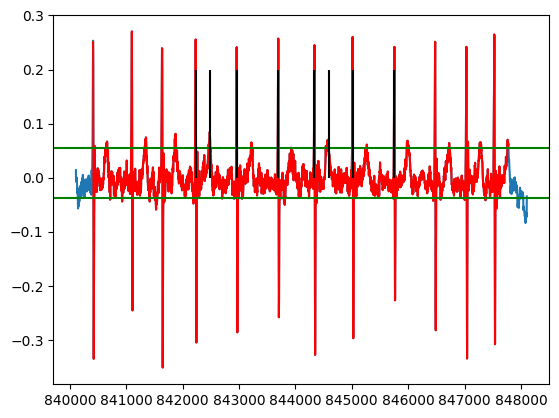

In [112]:
quantile = 0.05
pat = 'patient006'
seg = 'seg01'
channel = 'II'
v = time_df.loc[(time_df.patient==pat) & (time_df.segment==seg)][channel]
vindcs = v.index
q95 = time_df.loc[(time_df.patient==pat) & (time_df.segment==seg)][channel].quantile(1-quantile)
q05 = time_df.loc[(time_df.patient==pat) & (time_df.segment==seg)][channel].quantile(quantile)
pot_indices = v[v>q95].index
begin = pot_indices[10]
end = pot_indices[-10]

from scipy.signal import find_peaks, find_peaks_cwt
peaks, _ = find_peaks(v, height=q95, distance=100, prominence=0.1)
inner_peaks_num = 8
num_peaks = len(peaks)
inner_peaks = peaks[num_peaks//2-inner_peaks_num//2:num_peaks//2+inner_peaks_num//2]
indcs_peaks = vindcs[inner_peaks]

plt.plot(v)
plt.plot(v.loc[begin:end], color='red')
plt.axhline(q95, color='green')
plt.axhline(q05, color='green')
plt.vlines(indcs_peaks, ymin=0, ymax=0.2, color='black')

In [ ]:
time_df =  _trim_segment(time_df)
time_df =  _filter_segment(time_df)

In [ ]:
time_df.loc[:, meas_columns] = PowerTransformer().fit_transform(time_df.loc[:, meas_columns])
time_df, meas_columns = _feature_combiner(time_df, value_columns=meas_columns)

In [ ]:
time_df.to_parquet('wilson_central_terminal_ecg.parquet')
#time_df = pd.read_parquet('./wilson_central_terminal_ecg.parquet', engine='fastparquet')

In [ ]:
gc.collect()

Note: we stitched the 4 segments together without regard for their alignment, this should popout in any embedding.

## Silly embedding and clustering

In [ ]:
from umap import UMAP
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA, FastICA
from sklearn.cross_decomposition import PLSSVD,CCA

from tslearn import metrics as ts_metrics
from tslearn.clustering import TimeSeriesKMeans

In [ ]:
reducer = UMAP(n_components=6, n_neighbors=25, min_dist=0., random_state=42, n_epochs=1000)
#reducer = PCA(n_components=6) 
separator = FastICA() # time-complexity O(d^2*n*m), space O(d^2*n*m)

In [ ]:
ignore_cols = [c for c in time_df.columns if ('UV' in c) or ('WCT' in c)]
time_df.drop(ignore_cols, axis=1, inplace=True, errors='ignore')

In [ ]:
value_columns = [c for c in time_df.columns if c not in meta_cols]

In [ ]:
lepipe = Pipeline([('scaler', MinMaxScaler()),
                   ('reducer', reducer),
                   ('separator', separator)], verbose=True)

In [ ]:
num_patients=10
max_num = time_df.patient.nunique()
pat_sel = time_df.patient.unique()[np.random.randint(0, max_num, num_patients, replace=False)]
proc_df = time_df.loc[time_df.patient.isin(pat_sel), value_columns]
sel_indcs = proc_df.index
time_df_reduced = pd.DataFrame(data=lepipe.fit_transform(proc_df), 
                               columns=['d1','d2', 'd3', 'd4', 'd5', 'd6'], 
                               index=sel_indcs)
time_df_reduced = time_df_reduced.join(time_df[meta_cols])

In [ ]:
fig, ax = plt.subplots(figsize=(18,14), ncols=3, nrows=4)
df_M = time_df_reduced.loc[time_df.sex=='M'].sample(10000)
sns.scatterplot(data=df_M, x='d1', y='d2', s=30, alpha=0.1, ax=ax[0,0], hue='age', legend=False)
sns.scatterplot(data=df_M, x='d1', y='d3', s=30, alpha=0.1, ax=ax[0,1], hue='age', legend=False)
sns.scatterplot(data=df_M, x='d2', y='d3', s=30, alpha=0.1, ax=ax[0,2], hue='age', legend=False)
sns.scatterplot(data=df_M, x='d1', y='d4', s=30, alpha=0.1, ax=ax[1,0], hue='age', legend=False)
sns.scatterplot(data=df_M, x='d1', y='d5', s=30, alpha=0.1, ax=ax[1,1], hue='age', legend=False)
sns.scatterplot(data=df_M, x='d2', y='d6', s=30, alpha=0.1, ax=ax[1,2], hue='age', legend=False)

df_F = time_df_reduced.loc[time_df.sex=='F'].sample(10000)
sns.scatterplot(data=df_F, x='d1', y='d2', s=30, alpha=0.1, ax=ax[2,0], hue='age', legend=False)
sns.scatterplot(data=df_F, x='d1', y='d3', s=30, alpha=0.1, ax=ax[2,1], hue='age', legend=False)
sns.scatterplot(data=df_F, x='d2', y='d3', s=30, alpha=0.1, ax=ax[2,2], hue='age', legend=False)
sns.scatterplot(data=df_F, x='d1', y='d4', s=30, alpha=0.1, ax=ax[3,0], hue='age', legend=False)
sns.scatterplot(data=df_F, x='d1', y='d5', s=30, alpha=0.1, ax=ax[3,1], hue='age', legend=False)
sns.scatterplot(data=df_F, x='d2', y='d6', s=30, alpha=0.1, ax=ax[3,2], hue='age', legend=False)

In [ ]:
#eps = 1e-3
#plt.scatter(x=time_df_reduced.index, y=(time_df_reduced['d2']+eps)/(time_df_reduced['d1']+eps), s=2)
gc.collect()

In [ ]:
plot_df = time_df_reduced.loc[time_df_reduced.patient=='patient025'].melt(id_vars=['patient', 'segment', 'seg_index'], 
                                                                          value_vars=['d1','d2','d3', 'd4', 'd5', 'd6'])

sns.relplot(data=plot_df, x='seg_index', y='value', 
            hue='segment', col_wrap=3, 
            kind='line', col='variable',
            height=3, aspect=1.5, legend=True)

## Trim segments

Goal: remove inter-segment phase shifts

Strategy:
* identify first peak -> each segment get's a startIndex
* identify last peak -> each segment get's an endIndex
* align peaks, shift alle segments to startIndex
* keep until min(segLen, endIndex)


In [ ]:
ts = time_df_reduced.loc[(time_df_reduced.segment=='seg01') & (time_df_reduced.patient=='patient025')].d1

q98 = ts.quantile(0.95)
fPeakFirst = ts.loc[ts>=q98].index[0]
fPeakLast = ts.loc[ts>=q98].index[-1]


ts.plot()
plt.axhline(q98, color='r')
plt.axvline(fPeakFirst, color='r')
plt.axvline(fPeakLast, color='r')

plt.plot(ts.loc[fPeakFirst:fPeakLast], color='green')

In [ ]:
# get all the indices
# loop over all the patients
# loop over all the segments
# get the first peak and the last peak
keep_ranges = []
for pat in tqdm(time_df_reduced.patient.unique()):
    for seg in time_df_reduced.loc[time_df_reduced.patient==pat].segment.unique():
        ts = time_df_reduced.loc[(time_df_reduced.segment==seg) & (time_df_reduced.patient==pat)].d1
        q98 = ts.quantile(0.98)
        fPeakFirst = ts.loc[ts>=q98].index[0]
        fPeakLast = ts.loc[ts>=q98].index[-1]
        keep_ranges.append((pat, seg, fPeakFirst, fPeakLast))


In [ ]:
# Given a list of tuples, containing first peak and last peak index trim the dataframe
def _trim_index(keep_ranges):
    keep_index = []
    for _, _, fPeakFirst, fPeakLast in tqdm(keep_ranges):
        keep_index.extend(list(range(fPeakFirst, fPeakLast+1)))
    return keep_index

In [ ]:
keep_index = _trim_index(keep_ranges)

In [ ]:
time_df_reduced = time_df_reduced.loc[keep_index]

In [ ]:
gc.collect()

The time-evolution of the reduced dimension is quite regular. We can use this as an **intermediate step** to perform the timeseries clustering.

## Frequency based features

* find periodicity using PSD
* add Mel spectrogram

In [ ]:
from scipy import signal as sgn
import librosa

In [ ]:
plot_df = time_df_reduced.loc[time_df_reduced.patient=='patient036'].melt(id_vars=['patient', 'segment', 'seg_index'], 
                                                                          value_vars=['d1','d2','d3'])

time = plot_df.loc[(plot_df.variable=='d1') & (plot_df.segment=='seg01')].seg_index.values
signal = plot_df.loc[(plot_df.variable=='d1') & (plot_df.segment=='seg01')]['value'].values


In [ ]:
f, Pxx = sgn.periodogram(signal, fs=32)
#mel_spectrum = librosa.feature.melspectrogram(signal, sr=16, n_mels=256)
#S_dB = librosa.power_to_db(mel_spectrum, ref=np.max)

In [ ]:
import matplotlib.pyplot as plt
plt.semilogy(f[1:], Pxx[1:])
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()

## Less silly embedding and clustering

* add https://maelfabien.github.io/machinelearning/Speech9/#11-fundamental-frequency
* add spectral entropy
* use periodicity to extract sliding windows 
* treat windows as samples | treat segments as samples
* using multivariate DWT or other TS-similarity measure
* cluster


In [ ]:
if sampling_method == 'stride':
    # this is for strided windows
    # suppose you assume the scan window is 250 samples
    sample_window = 500
    # now we want to have a moving window selection with a stride of 50
    stride_step = 100
    # number of dimensions
    num_dims = 3
    # number of windows
    num_windows = int(len(time_df_reduced)/stride_step)

    # list of windows
    time_windows = []
    time_windows_arr = np.zeros((num_windows,sample_window,num_dims))
    num_windows = int(len(time_df)/stride_step)
    for i in range(num_windows):
        ib = i*stride_step
        ie = sample_window+i*stride_step
        tmp = time_df.iloc[ib:ie]
        arr = tmp.values
        ns,nd = arr.shape
        time_windows_arr[i][0:ns,0:nd]= arr
        tmp = tmp.assign(window = i)
        time_windows.append(tmp)
    expanded_df = pd.concat(time_windows)
    #expanded_arr = np.asarray(time_windows_arr)

In [ ]:
# this is for trimmed segments
segment_lengths = [t[3]-t[2] for t in keep_ranges]
plt.hist(segment_lengths, bins=50);
print(f'min:{min(segment_lengths)}, max:{max(segment_lengths)}, mean:{np.mean(segment_lengths)}, std:{np.std(segment_lengths)}')

In [ ]:
time_df_reduced.loc[keep_ranges[i][2]:keep_ranges[i][2]+min_seg_len]

In [ ]:
if sampling_method == 'trimmed_segment':
    value_columns = ['d1','d2','d3']
    min_seg_len = min(segment_lengths)
    num_dims = 3
    num_windows = len(keep_ranges)
    time_windows_arr = np.zeros((num_windows,min_seg_len,num_dims))
    for i in range(num_windows):
        tmp = time_df_reduced.loc[keep_ranges[i][2]:keep_ranges[i][2]+min_seg_len, value_columns]
        arr = tmp.values
        ns,nd = arr.shape
        time_windows_arr[i][0:min_seg_len]= arr
        tmp = tmp.assign(window = i)
        time_windows.append(tmp)
    expanded_df = pd.concat(time_windows)        
    

In [ ]:
dba_km = TimeSeriesKMeans(n_clusters=8,
                          n_init=2,
                          n_jobs=4,
                          metric="dtw", # softdtw
                          verbose=False,
                          max_iter_barycenter=20,
                          random_state=2132)
c_predict = dba_km.fit_predict(time_windows_arr)

In [ ]:
distance_arr = np.zeros((640,640))
for i in range(640):
    for j in range(640):        
        ts1 = expanded_df.loc[expanded_df.window==i]
        ts2 = expanded_df.loc[expanded_df.window==j]
        distance_arr[i,j] = ts_metrics.dtw(ts1,ts2)

In [ ]:
reducer = UMAP(n_components=2, metric='precomputed')
dtw_reduced = pd.DataFrame(data=reducer.fit_transform(distance_arr),columns=['d1','d2'])

In [ ]:
sns.scatterplot(data=dtw_reduced.reset_index(), x='d1', y='d2', s=10, hue='index')

In [ ]:
dtw_reduced.shape[0]/50

In [ ]:
dtw_reduced[dtw_reduced.d1<0].index*50+200

In [ ]:
fig, ax = plt.subplots(figsize=(18,6))
plt.plot(time_df['I'])
plt.plot(time_df['II'])
plt.plot(-time_df['III'])

plt.axvline(x=8000, color='r')
plt.axvline(x=8200, color='r')

plt.axvline(x=16000, color='b')
plt.axvline(x=16200, color='b')

plt.axvline(x=24000, color='g')
plt.axvline(x=24200, color='g')

## Fourier analysis

## Neural embeddings using LSTM-AE

e.g. [here](https://github.com/JulesBelveze/time-series-autoencoder), [here](https://github.com/chrisvdweth/ml-toolkit/tree/master/pytorch/models/text/autoencoder) and [here](https://medium.com/@jwbtmf/lstm-autoencoder-for-anomaly-detection-for-ecg-data-5c0b07d00e50)


## Neural embeddings using T-LSTM-AE


## ECGxAI

[vAE, Rutger et al](https://github.com/bramiozo/ecgxai)

## Time2Vec

[paper](https://arxiv.org/pdf/1907.05321.pdf)

## Motifs

The rage in TS country is "motifs", basically discernible traits in timeseries. 

We have to be aware a bit of Ramsay's theory: *a sequence of n^2+1 will have at least one orderd subsequence of length n+1*.

# Foreceasting models

* [conformal time-series forecasting](https://proceedings.neurips.cc/paper/2021/hash/312f1ba2a72318edaaa995a67835fad5-Abstract.html)
* [explaining time-series forecasting](http://proceedings.mlr.press/v139/crabbe21a.html)


